In [9]:
train_list_path = "data/geopose3k/geoPose3K_final_publish/geoPose3K_final_train.txt"
val_list_path = "data/geopose3k/geoPose3K_final_publish/geoPose3K_final_val.txt"
base_dataset_dir = "data/geopose3k/geoPose3K_final_publish"

train_images, train_masks = [], []
val_images, val_masks = [], []

In [10]:
import os

In [11]:
if os.path.exists(train_list_path):
    with open(train_list_path, "r") as f:
        for line in f:
            folder_name = line.strip()
            img_path = os.path.join(base_dataset_dir, folder_name, "cyl/photo_crop.jpg")
            mask_path = os.path.join(base_dataset_dir, folder_name, "cyl/labels_crop.png")
            if os.path.exists(img_path) and os.path.exists(mask_path):
                train_images.append(img_path)
                train_masks.append(mask_path)

In [12]:
if os.path.exists(val_list_path):
    with open(val_list_path, "r") as f:
        for line in f:
            folder_name = line.strip()
            img_path = os.path.join(base_dataset_dir, folder_name, "cyl/photo_crop.jpg")
            mask_path = os.path.join(base_dataset_dir, folder_name, "cyl/labels_crop.png")
            if os.path.exists(img_path) and os.path.exists(mask_path):
                val_images.append(img_path)
                val_masks.append(mask_path)

In [13]:
syn_img_dir = "data/synthetic_dataset/images"
syn_mask_dir = "data/synthetic_dataset/masks"

In [14]:
if os.path.exists(syn_img_dir):
    for f in sorted(os.listdir(syn_img_dir)):
        if f.endswith(".png"):
            train_images.append(os.path.join(syn_img_dir, f))
            train_masks.append(os.path.join(syn_mask_dir, f))

Let's print the first five train/validation images and masks.

In [15]:
train_images[:5]

['data/geopose3k/geoPose3K_final_publish/28488116812_f5a57ca0f6_k/cyl/photo_crop.jpg',
 'data/geopose3k/geoPose3K_final_publish/28561570606/cyl/photo_crop.jpg',
 'data/geopose3k/geoPose3K_final_publish/eth_ch1_1332166_01024/cyl/photo_crop.jpg',
 'data/geopose3k/geoPose3K_final_publish/eth_ch1_2011-04-30_18:37:52_01024/cyl/photo_crop.jpg',
 'data/geopose3k/geoPose3K_final_publish/eth_ch1_2011-04-30_18:40:20_01024/cyl/photo_crop.jpg']

In [16]:
train_masks[:5]

['data/geopose3k/geoPose3K_final_publish/28488116812_f5a57ca0f6_k/cyl/labels_crop.png',
 'data/geopose3k/geoPose3K_final_publish/28561570606/cyl/labels_crop.png',
 'data/geopose3k/geoPose3K_final_publish/eth_ch1_1332166_01024/cyl/labels_crop.png',
 'data/geopose3k/geoPose3K_final_publish/eth_ch1_2011-04-30_18:37:52_01024/cyl/labels_crop.png',
 'data/geopose3k/geoPose3K_final_publish/eth_ch1_2011-04-30_18:40:20_01024/cyl/labels_crop.png']

In [17]:
val_images[:5]

['data/geopose3k/geoPose3K_final_publish/eth_ch1_04032011388_01024/cyl/photo_crop.jpg',
 'data/geopose3k/geoPose3K_final_publish/eth_ch1_04032011389_01024/cyl/photo_crop.jpg',
 'data/geopose3k/geoPose3K_final_publish/eth_ch1_04032011390_01024/cyl/photo_crop.jpg',
 'data/geopose3k/geoPose3K_final_publish/eth_ch1_04032011391_01024/cyl/photo_crop.jpg',
 'data/geopose3k/geoPose3K_final_publish/eth_ch1_2011-10-04_14:25:54_01024/cyl/photo_crop.jpg']

In [18]:
val_masks[:5]

['data/geopose3k/geoPose3K_final_publish/eth_ch1_04032011388_01024/cyl/labels_crop.png',
 'data/geopose3k/geoPose3K_final_publish/eth_ch1_04032011389_01024/cyl/labels_crop.png',
 'data/geopose3k/geoPose3K_final_publish/eth_ch1_04032011390_01024/cyl/labels_crop.png',
 'data/geopose3k/geoPose3K_final_publish/eth_ch1_04032011391_01024/cyl/labels_crop.png',
 'data/geopose3k/geoPose3K_final_publish/eth_ch1_2011-10-04_14:25:54_01024/cyl/labels_crop.png']

In [43]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import numpy as np
from PIL import Image

In the UNet model, we're using MobileNet encoder, which was pretrained on ImageNet dataset.

They were normalized and had the following standard deviations and means.

The images we provide to our UNet must have this normalization. When we plot, we have to denormalize (because values can be negative).

In [54]:
imagenet_standard_deviation = [0.229, 0.224, 0.225]
imagenet_mean = [0.485, 0.456, 0.406]

In [55]:
class UnifiedDataset(Dataset):
    def __init__(self, imgs, masks):
        self.imgs = imgs
        self.masks = masks

        self.img_trans = T.Compose([
            T.Resize(256),
            T.CenterCrop(256), # Cropped to 256x256 to remove the black edges due to projection
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Brightness, Contrast, Saturation randomly changed for robustness
            T.ToTensor(),
            T.Normalize(mean=imagenet_mean, std=imagenet_standard_deviation)
        ])
        self.mask_trans = T.Compose([
            T.Resize(256, interpolation=T.InterpolationMode.NEAREST),  # Keeps values 0, 255 (binary) instead of interpolating to middle values.
            T.CenterCrop(256), # Cropped to be same size as the photograph
            T.ToTensor()
        ])

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img = self.img_trans(Image.open(self.imgs[idx]).convert("RGB"))
        
        # Load mask and process labels to binary (Sky = 255, Terrain = 0)
        mask_raw = Image.open(self.masks[idx]).convert("L")
        mask_np = np.array(mask_raw)
        
        if "synthetic_dataset" in self.imgs[idx]:
            # Synthetic: Sky is already 255, Terrain is 0
            binary_sky = mask_np
        else:
            # GeoPose3K: Sky is 0
            binary_sky = (mask_np == 0).astype(np.uint8) * 255
            
        mask_pil = Image.fromarray(binary_sky)
        mask = self.mask_trans(mask_pil)
        return img, mask

In [45]:
train_loader = DataLoader(UnifiedDataset(train_images, train_masks), batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(UnifiedDataset(val_images, val_masks), batch_size=8, shuffle=False, num_workers=2)

print(f"Data loaders configured. Train samples: {len(train_images)} | Val samples: {len(val_images)}")

Data loaders configured. Train samples: 2580 | Val samples: 515


In [46]:
import torch.nn as nn
import segmentation_models_pytorch as smp

In [47]:
# Force headless EGL rendering backend
os.environ['PYRENDER_BACKEND'] = 'egl'

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

Running on device: cpu


In [48]:
# Create model architecture
model = smp.Unet(
    encoder_name="tu-mobilenetv3_large_100",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

Unexpected keys (classifier.bias, classifier.weight, conv_head.bias, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


In [49]:
epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for val_images, val_masks in val_loader:
            val_images, val_masks = val_images.to(device), val_masks.to(device)
            val_outputs = model(val_images)
            v_loss = criterion(val_outputs, val_masks)
            val_loss += v_loss.item()
            
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {total_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

# Save the trained parameters
torch.save(model.state_dict(), "data/best_sky_unet.pth")

Epoch 1/5 | Train Loss: 0.1929 | Val Loss: 0.0885
Epoch 2/5 | Train Loss: 0.0599 | Val Loss: 0.0547
Epoch 3/5 | Train Loss: 0.0457 | Val Loss: 0.0456
Epoch 4/5 | Train Loss: 0.0320 | Val Loss: 0.0436
Epoch 5/5 | Train Loss: 0.0288 | Val Loss: 0.0404


In [51]:
import matplotlib.pyplot as plt

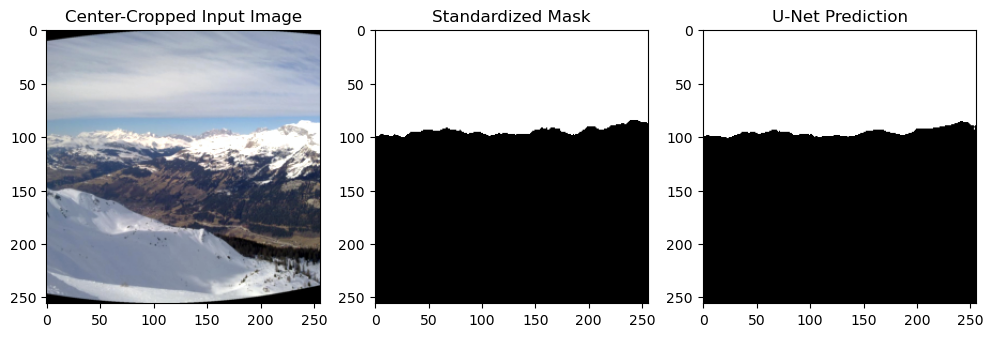

In [56]:
model.eval()

# Grab a validation batch
images, masks = next(iter(val_loader))

with torch.no_grad():
    outputs = model(images.to(device))
    preds = torch.sigmoid(outputs).cpu().numpy()

# Denormalize image for correct RGB visualization
sample_img = images[0].permute(1, 2, 0).numpy() # Pytorch expects [Channels, Height, Width] 
                                                # Matplotlib expects [Height, Width, Channels]
sample_img = np.clip(sample_img * imagenet_standard_deviation + imagenet_mean, 0, 1)

# Plot results
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(sample_img)
ax[0].set_title("Center-Cropped Input Image")
ax[1].imshow(masks[0][0], cmap="gray")
ax[1].set_title("Standardized Mask")
ax[2].imshow(preds[0][0] > 0.5, cmap="gray")
ax[2].set_title("U-Net Prediction")
plt.show()

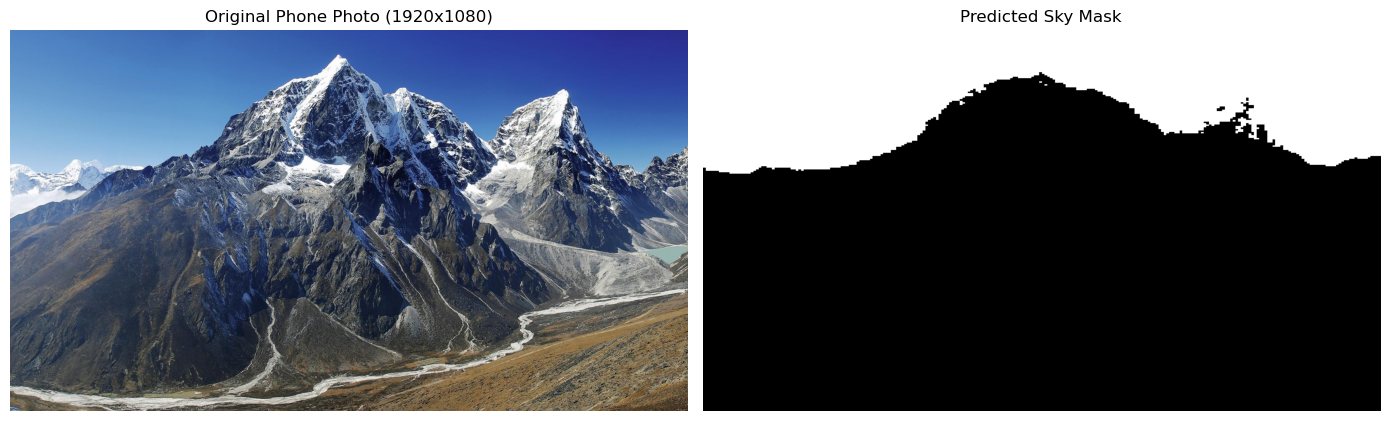

In [64]:
image_path = "data/test.jpg"

model.eval()

if os.path.exists(image_path):
    raw_img = Image.open(image_path).convert("RGB")
    original_width, original_height = raw_img.size
    
    # Squash image to 256x256 for U-Net
    eval_transform = T.Compose([
        T.Resize((256, 256)),
        T.ToTensor(),
        T.Normalize(mean=imagenet_mean, std=imagenet_standard_deviation)
    ])
    img_tensor = eval_transform(raw_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(img_tensor)
        pred_mask = torch.sigmoid(output).squeeze(0).cpu().numpy()[0]

    # pred_mask has probabilities between 0 and 1.
    # We create binary mask which has only values 0 (not sky) and 255 (sky).
    # Stretch back to the original aspect ratio
    binary_mask_np = ((pred_mask > 0.5) * 255).astype(np.uint8)
    binary_mask_pil = Image.fromarray(binary_mask_np)
    
    # Resize back using Nearest-Neighbor to keep the transition pixel-sharp
    final_full_frame_mask = binary_mask_pil.resize(
        (original_width, original_height), 
        resample=Image.Resampling.NEAREST
    )
    
    # Plot the original image and the stretched mask
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    ax[0].imshow(raw_img)
    ax[0].set_title(f"Original Phone Photo ({original_width}x{original_height})")
    ax[0].axis("off")
    
    ax[1].imshow(final_full_frame_mask, cmap="gray")
    ax[1].set_title("Predicted Sky Mask")
    ax[1].axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Error: '{image_path}' not found in directory.")